<a href="https://colab.research.google.com/github/Raju-mia-RK/Raju/blob/colab_work/cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,confusion_matrix,classification_report,
    precision_score,recall_score,f1_score,roc_curve,roc_auc_score,auc

)
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('/content/drive/MyDrive/datasets/Breast_Cancer_Wisconsin_Dataset.csv')

Mounted at /content/drive


In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.shape

(569, 33)

In [7]:
df.columns.tolist()

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32']

In [8]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [27]:
df['diagnosis_numeric']=df['diagnosis'].map({'M':1,'B':0})
important_feature=[
    'perimeter_mean',

    'concave points_mean',
    'concavity_worst',
    'concave points_worst',
    'radius_worst'
]

x=df[important_feature]
y=df['diagnosis_numeric']
x.shape
y.shape

(569,)

In [28]:
y.head()

,diagnosis_numeric
0,1
1,1
2,1
3,1
4,1


In [29]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
x_train.head()

,perimeter_mean,concave points_mean,concavity_worst,concave points_worst,radius_worst
68,58.79,0.04375,1.25200,0.17500,10.31
181,142.70,0.14960,0.67800,0.29030,26.68
63,59.20,0.02180,0.13970,0.05087,10.01
248,68.01,0.01615,0.11250,0.06136,12.25
60,64.55,0.01290,0.02168,0.02579,11.02


In [30]:
y_test.head()

,diagnosis_numeric
204,0
70,1
131,1
431,0
540,0


In [39]:
skillmorph_doctor=DecisionTreeClassifier(
    max_depth=3,
    random_state=40

)
skillmorph_doctor.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=40)

In [40]:
prediction=skillmorph_doctor.predict(x_test)
accuracy=accuracy_score(y_test,prediction)
if accuracy>0.95:
  print(f"Excellent out skill morph doctor is very accurate: {accuracy*100:.1f}%")
elif accuracy>0.90:
  print(f"Very good out skill morph doctor is accurate: {accuracy*100:.1f}%")
elif accuracy>0.80:
  print(f"Good out skill morph doctor is accurate: {accuracy*100:.1f}%")
else:
  print("Need improvement.....")

Very good out skill morph doctor is accurate: 93.9%


[[69  2]
 [ 5 38]]
Correct: 107
Wrong: 7


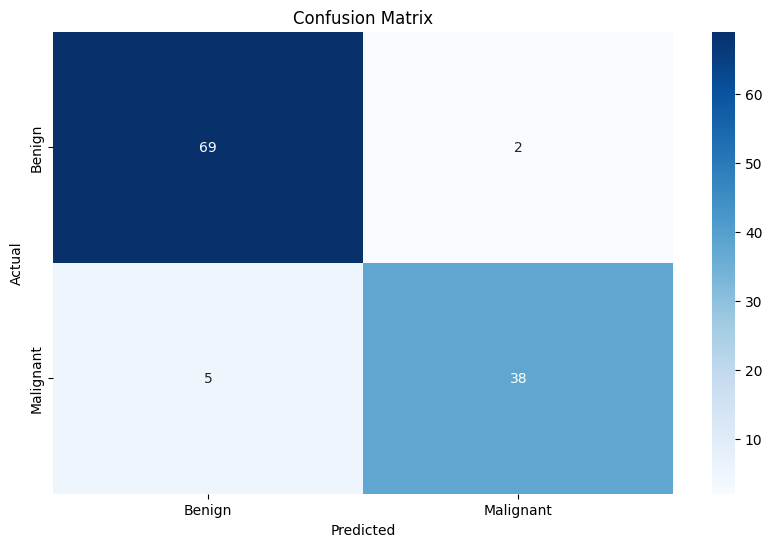

In [41]:
cm=confusion_matrix(y_test,prediction)
print(cm)
print(f"Correct: {cm[0,0]+cm[1,1 ]}")
print(f"Wrong: {cm[0,1]+cm[1,0]}")
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy: 0.94
Precision: 0.95
Recall: 0.88
F1 Score: 0.92


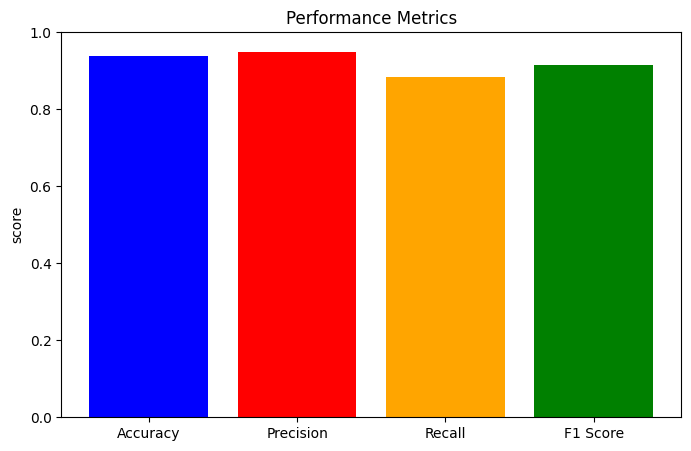

In [42]:
accuracy=accuracy_score(y_test,prediction)
precision=precision_score(y_test,prediction)
recall=recall_score(y_test,prediction)
f1=f1_score(y_test,prediction)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

plt.figure(figsize=(8,5))
metrics=['Accuracy','Precision','Recall','F1 Score']
values=[accuracy,precision,recall,f1]
plt.bar(metrics,values,color=['blue','red','orange','green'])
plt.ylim(0,1)
plt.title('Performance Metrics')
plt.ylabel('score')
plt.show()
